In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [6]:
# ============================================================
# Q15 - ENGLISH TO TELUGU ENCODER-DECODER MODEL
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split


# ============================================================
# 1. LOAD DATASET
# ============================================================

DATA_PATH = "/kaggle/input/datasets/jyothiradhityach/eng-tel-transcrib/english_telugu_translation.csv"

data = pd.read_csv(DATA_PATH)

print("TensorFlow Version:", tf.__version__)
print("Dataset Shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

print("\nFirst 5 rows:")
display(data.head())


# ============================================================
# 2. CLEAN DATA
# ============================================================

data = data[["english", "telugu"]].copy()

data = data.dropna()

data["english"] = data["english"].astype(str).str.strip()
data["telugu"] = data["telugu"].astype(str).str.strip()

data = data[
    (data["english"] != "") &
    (data["telugu"] != "")
]

print("\nClean Dataset Shape:", data.shape)


# ============================================================
# 3. PREPARE ENGLISH AND TELUGU SENTENCES
# ============================================================

english_sentences = data["english"].tolist()

telugu_sentences = [
    "<START> " + sentence + " <END>"
    for sentence in data["telugu"].tolist()
]


# ============================================================
# 4. TRAIN-TEST SPLIT
# ============================================================

eng_train, eng_test, tel_train, tel_test = train_test_split(
    english_sentences,
    telugu_sentences,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(eng_train))
print("Testing samples :", len(eng_test))


# ============================================================
# 5. ENGLISH TOKENIZER
# ============================================================

eng_tokenizer = Tokenizer(
    filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n'
)

eng_tokenizer.fit_on_texts(eng_train)

eng_train_seq = eng_tokenizer.texts_to_sequences(eng_train)
eng_test_seq = eng_tokenizer.texts_to_sequences(eng_test)

eng_vocab_size = len(eng_tokenizer.word_index) + 1

max_encoder_length = max(
    len(seq) for seq in eng_train_seq
)


# ============================================================
# 6. TELUGU TOKENIZER
# ============================================================

tel_tokenizer = Tokenizer(
    filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n'
)

tel_tokenizer.fit_on_texts(tel_train)

tel_train_seq = tel_tokenizer.texts_to_sequences(tel_train)
tel_test_seq = tel_tokenizer.texts_to_sequences(tel_test)

tel_vocab_size = len(tel_tokenizer.word_index) + 1

max_decoder_length = max(
    len(seq) for seq in tel_train_seq
)


# ============================================================
# 7. PAD ENGLISH INPUT
# ============================================================

encoder_input_data = pad_sequences(
    eng_train_seq,
    maxlen=max_encoder_length,
    padding="post"
)


# ============================================================
# 8. PAD TELUGU SEQUENCES
# ============================================================

decoder_full_data = pad_sequences(
    tel_train_seq,
    maxlen=max_decoder_length,
    padding="post"
)


# ============================================================
# 9. DECODER INPUT AND TARGET
# ============================================================

# Decoder input:
# <START> నేను బాగున్నాను

decoder_input_data = decoder_full_data[:, :-1]


# Decoder target:
# నేను బాగున్నాను <END>

decoder_target_data = decoder_full_data[:, 1:]

decoder_target_data = np.expand_dims(
    decoder_target_data,
    -1
)


# ============================================================
# 10. MODEL PARAMETERS
# ============================================================

embedding_dim = 128
latent_dim = 256


print("\n============================================================")
print("VOCABULARY INFORMATION")
print("============================================================")

print("English Vocabulary Size:", eng_vocab_size)
print("Telugu Vocabulary Size :", tel_vocab_size)

print("Maximum Encoder Length:", max_encoder_length)
print("Maximum Decoder Length:", max_decoder_length)


# ============================================================
# 11. ENCODER
# ============================================================

encoder_inputs = Input(
    shape=(max_encoder_length,),
    name="encoder_input"
)

encoder_embedding_layer = Embedding(
    input_dim=eng_vocab_size,
    output_dim=embedding_dim,
    mask_zero=True,
    name="encoder_embedding"
)

encoder_embedding = encoder_embedding_layer(
    encoder_inputs
)

encoder_lstm = LSTM(
    latent_dim,
    return_state=True,
    name="encoder_lstm"
)

encoder_outputs, state_h, state_c = encoder_lstm(
    encoder_embedding
)

encoder_states = [state_h, state_c]


# ============================================================
# 12. DECODER
# ============================================================

decoder_inputs = Input(
    shape=(max_decoder_length - 1,),
    name="decoder_input"
)

decoder_embedding_layer = Embedding(
    input_dim=tel_vocab_size,
    output_dim=embedding_dim,
    mask_zero=True,
    name="decoder_embedding"
)

decoder_embedding = decoder_embedding_layer(
    decoder_inputs
)

decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm"
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding,
    initial_state=encoder_states
)


# ============================================================
# 13. OUTPUT LAYER
# ============================================================

decoder_dense = Dense(
    tel_vocab_size,
    activation="softmax",
    name="decoder_output"
)

decoder_outputs = decoder_dense(
    decoder_outputs
)


# ============================================================
# 14. COMPLETE ENCODER-DECODER MODEL
# ============================================================

model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)


# ============================================================
# 15. COMPILE MODEL
# ============================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# 16. MODEL SUMMARY
# ============================================================

print("\n============================================================")
print("ENCODER-DECODER MODEL")
print("============================================================")

model.summary()

TensorFlow Version: 2.20.0
Dataset Shape: (139, 2)

Columns:
['english', 'telugu']

First 5 rows:


,english,telugu
0,How are you?,మీరు ఎలా ఉన్నారు?
1,I am fine.,నేను బాగున్నాను.
2,What is your name?,మీ పేరు ఏమిటి?
3,My name is Ravi.,నా పేరు రవి.
4,Where do you live?,మీరు ఎక్కడ నివసిస్తున్నారు?



Clean Dataset Shape: (139, 2)

Training samples: 111
Testing samples : 28

VOCABULARY INFORMATION
English Vocabulary Size: 208
Telugu Vocabulary Size : 224
Maximum Encoder Length: 10
Maximum Decoder Length: 9


I0000 00:00:1789236212.089016      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789236212.091900      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



ENCODER-DECODER MODEL


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 10, 128)   │     26,624 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 10)        │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 8, 128)    │     28,672 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    394,240 │ encoder_embeddin… │
│                     │ (None, 256),      │            │ not_equal[0][0]   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 8, 256),  │    394,240 │ decoder_embeddin… │
│                     │ (None, 256),      │            │ encoder_lstm[0][… │
│                     │ (None, 256)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 8, 224)    │     57,568 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 901,344 (3.44 MB)

 Trainable params: 901,344 (3.44 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ============================================================
# Q15 - TRAIN THE ENCODER-DECODER MODEL
# ============================================================

EPOCHS = 100
BATCH_SIZE = 16

history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.10,
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.2595 - loss: 5.3828 - val_accuracy: 0.3636 - val_loss: 5.2863
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3282 - loss: 5.0130 - val_accuracy: 0.2576 - val_loss: 4.0989
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2096 - loss: 4.3002 - val_accuracy: 0.2727 - val_loss: 3.8552
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2818 - loss: 3.9692 - val_accuracy: 0.3636 - val_loss: 3.9864
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3230 - loss: 3.8566 - val_accuracy: 0.3636 - val_loss: 3.8894
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3385 - loss: 3.7285 - val_accuracy: 0.3636 - val_loss: 3.8543
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3814 - loss: 3.6044 - val_accuracy: 0.3788 - val_loss: 3.8040
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3694 - loss: 3.4852 - val_accuracy: 0.3788 - val_loss:

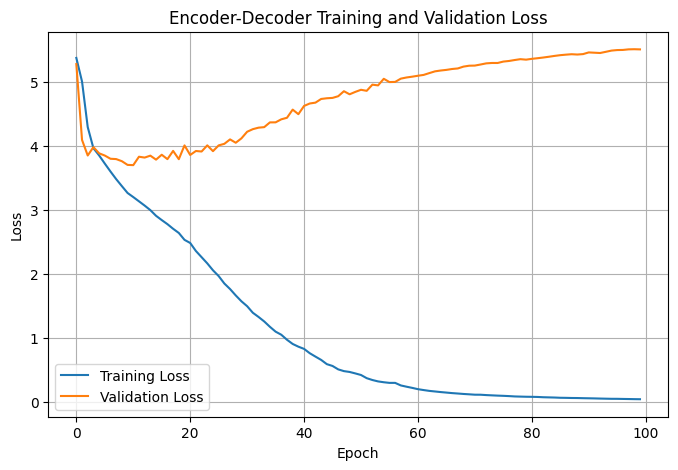

In [8]:
# ============================================================
# TRAINING AND VALIDATION LOSS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Encoder-Decoder Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

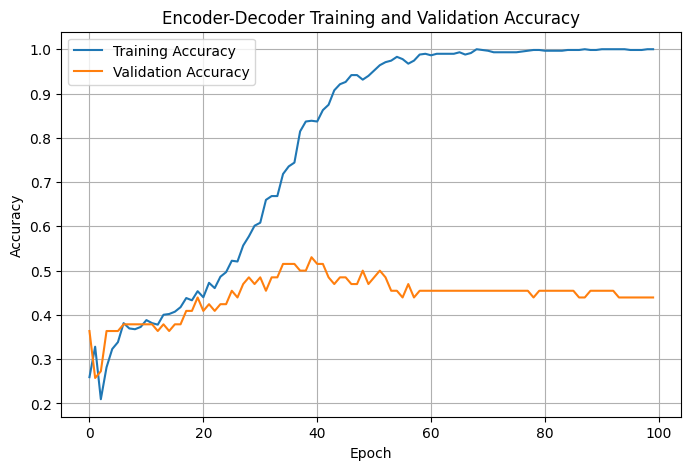

In [10]:
# ============================================================
# TRAINING AND VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Encoder-Decoder Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [11]:
# ============================================================
# Q16 - DEMONSTRATE ENCODER HIDDEN AND CELL STATES
# ============================================================

# Create a separate encoder model
encoder_model = Model(
    encoder_inputs,
    [encoder_outputs, state_h, state_c]
)

# Select one sentence
sample_sentence = "How are you?"

# Convert sentence to token sequence
sample_sequence = eng_tokenizer.texts_to_sequences(
    [sample_sentence]
)

# Pad it to the encoder input length
sample_padded = pad_sequences(
    sample_sequence,
    maxlen=max_encoder_length,
    padding="post"
)

# Generate encoder states
sample_output, sample_hidden, sample_cell = encoder_model.predict(
    sample_padded,
    verbose=0
)

print("============================================================")
print("Q16 - ENCODER STATE REPRESENTATION")
print("============================================================")

print("\nInput Sentence:")
print(sample_sentence)

print("\nToken Sequence:")
print(sample_sequence[0])

print("\nPadded Sequence:")
print(sample_padded[0])

print("\nEncoder Output Shape:")
print(sample_output.shape)

print("\nHidden State Shape:")
print(sample_hidden.shape)

print("\nCell State Shape:")
print(sample_cell.shape)

print("\nFirst 10 values of Hidden State:")
print(sample_hidden[0][:10])

print("\nFirst 10 values of Cell State:")
print(sample_cell[0][:10])

Q16 - ENCODER STATE REPRESENTATION

Input Sentence:
How are you?

Token Sequence:
[73, 5, 1]

Padded Sequence:
[73  5  1  0  0  0  0  0  0  0]

Encoder Output Shape:
(1, 256)

Hidden State Shape:
(1, 256)

Cell State Shape:
(1, 256)

First 10 values of Hidden State:
[ 0.5867241  -0.35597575  0.04544358 -0.2502345   0.06435777 -0.5374918
 -0.5176424   0.41848752 -0.13276178  0.06520225]

First 10 values of Cell State:
[ 0.95399916 -0.6438168   0.07342168 -0.4451144   0.0937154  -0.8410327
 -1.0575085   0.7098614  -0.39640945  0.08245035]


In [12]:
# ============================================================
# Q17 - DECODER USING ENCODER STATES
# ============================================================

print("============================================================")
print("Q17 - DECODER USING ENCODER STATES")
print("============================================================")

# ------------------------------------------------------------
# 1. CREATE DECODER MODEL
# ------------------------------------------------------------

decoder_model = Model(
    [decoder_inputs, encoder_inputs],
    decoder_outputs
)

print("\nDecoder Architecture:")
decoder_model.summary()


# ------------------------------------------------------------
# 2. DISPLAY ENCODER STATES FOR SAMPLE INPUT
# ------------------------------------------------------------

print("\nEncoder Hidden State:")
print("Shape:", sample_hidden.shape)

print("\nEncoder Cell State:")
print("Shape:", sample_cell.shape)


# ------------------------------------------------------------
# 3. GET THE EXPECTED TELUGU OUTPUT FOR THE SAMPLE
# ------------------------------------------------------------

sample_index = eng_test.index(sample_sentence) if sample_sentence in eng_test else None

if sample_index is not None:

    target_sentence = tel_test[sample_index]

    print("\nInput English Sentence:")
    print(sample_sentence)

    print("\nTarget Telugu Sentence:")
    print(target_sentence)

else:
    print("\nSample sentence is not in the test set.")
    print("The decoder architecture has still been successfully created.")


# ------------------------------------------------------------
# 4. DEMONSTRATE DECODER INPUT
# ------------------------------------------------------------

start_token_id = tel_tokenizer.word_index["<start>"]

print("\n<START> Token ID:")
print(start_token_id)

print("\nDecoder receives:")
print("1. <START> token")
print("2. Encoder hidden state")
print("3. Encoder cell state")

print("\nThe Decoder LSTM uses the encoder states")
print("as its initial state to generate Telugu tokens.")

Q17 - DECODER USING ENCODER STATES

Decoder Architecture:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 10, 128)   │     26,624 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 10)        │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 8, 128)    │     28,672 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    394,240 │ encoder_embeddin… │
│                     │ (None, 256),      │            │ not_equal[0][0]   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 8, 256),  │    394,240 │ decoder_embeddin… │
│                     │ (None, 256),      │            │ encoder_lstm[0][… │
│                     │ (None, 256)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 8, 224)    │     57,568 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 901,344 (3.44 MB)

 Trainable params: 901,344 (3.44 MB)

 Non-trainable params: 0 (0.00 B)


Encoder Hidden State:
Shape: (1, 256)

Encoder Cell State:
Shape: (1, 256)

Sample sentence is not in the test set.
The decoder architecture has still been successfully created.

<START> Token ID:
1

Decoder receives:
1. <START> token
2. Encoder hidden state
3. Encoder cell state

The Decoder LSTM uses the encoder states
as its initial state to generate Telugu tokens.


In [15]:
# ============================================================
# Q18 - FIXED INFERENCE DECODER
# ============================================================

print("============================================================")
print("Q18 - FIXED START/END TOKEN DECODING")
print("============================================================")


# ------------------------------------------------------------
# 1. CREATE ENCODER INFERENCE MODEL WITHOUT MASKING
# ------------------------------------------------------------
# The trained Encoder uses mask_zero=True.
# For inference, we create a copy of the embedding layer
# without masking to avoid the cuDNN mask assertion.

encoder_inference_input = Input(
    shape=(max_encoder_length,),
    name="encoder_inference_input"
)

encoder_inference_embedding_layer = Embedding(
    input_dim=eng_vocab_size,
    output_dim=embedding_dim,
    mask_zero=False,
    name="encoder_inference_embedding"
)

encoder_inference_embedding = encoder_inference_embedding_layer(
    encoder_inference_input
)

# Copy trained embedding weights
encoder_inference_embedding_layer.set_weights(
    encoder_embedding_layer.get_weights()
)

# Use the already-trained Encoder LSTM
_, inference_hidden_state, inference_cell_state = encoder_lstm(
    encoder_inference_embedding
)

encoder_inference_model = Model(
    encoder_inference_input,
    [inference_hidden_state, inference_cell_state]
)


# ------------------------------------------------------------
# 2. CREATE DECODER INFERENCE MODEL
# ------------------------------------------------------------

decoder_state_h_input = Input(
    shape=(latent_dim,),
    name="decoder_hidden_input"
)

decoder_state_c_input = Input(
    shape=(latent_dim,),
    name="decoder_cell_input"
)

decoder_single_input = Input(
    shape=(1,),
    name="decoder_single_input"
)

decoder_states_inputs = [
    decoder_state_h_input,
    decoder_state_c_input
]

decoder_single_embedding = decoder_embedding_layer(
    decoder_single_input
)

decoder_single_output, decoder_h, decoder_c = decoder_lstm(
    decoder_single_embedding,
    initial_state=decoder_states_inputs
)

decoder_single_output = decoder_dense(
    decoder_single_output
)

decoder_inference_model = Model(
    [
        decoder_single_input,
        decoder_state_h_input,
        decoder_state_c_input
    ],
    [
        decoder_single_output,
        decoder_h,
        decoder_c
    ]
)


# ------------------------------------------------------------
# 3. REVERSE TELUGU VOCABULARY
# ------------------------------------------------------------

reverse_telugu_word_index = {
    index: word
    for word, index in tel_tokenizer.word_index.items()
}


# ------------------------------------------------------------
# 4. START AND END TOKENS
# ------------------------------------------------------------

start_token_id = tel_tokenizer.word_index["<start>"]
end_token_id = tel_tokenizer.word_index["<end>"]

print("START token ID:", start_token_id)
print("END token ID  :", end_token_id)


# ------------------------------------------------------------
# 5. TRANSLATION FUNCTION
# ------------------------------------------------------------

def translate_sentence(sentence):

    # Convert English sentence into token IDs
    input_sequence = eng_tokenizer.texts_to_sequences(
        [sentence]
    )

    # Right-pad the sequence
    input_sequence = pad_sequences(
        input_sequence,
        maxlen=max_encoder_length,
        padding="post",
        truncating="post"
    )

    # Encode the English sentence
    hidden_state, cell_state = encoder_inference_model.predict(
        input_sequence,
        verbose=0
    )

    # Begin decoding with <START>
    target_token = np.array([[start_token_id]])

    translated_words = []

    for _ in range(max_decoder_length):

        # Predict the next token
        output_tokens, hidden_state, cell_state = (
            decoder_inference_model.predict(
                [
                    target_token,
                    hidden_state,
                    cell_state
                ],
                verbose=0
            )
        )

        # Select the most probable token
        predicted_token_id = int(
            np.argmax(output_tokens[0, -1, :])
        )

        # Stop when <END> is generated
        if predicted_token_id == end_token_id:
            break

        # Convert token ID back to Telugu word
        predicted_word = reverse_telugu_word_index.get(
            predicted_token_id,
            ""
        )

        if predicted_word:
            translated_words.append(predicted_word)

        # Feed predicted token back into decoder
        target_token = np.array(
            [[predicted_token_id]]
        )

    return " ".join(translated_words)


# ------------------------------------------------------------
# 6. TEST Q18 AGAIN
# ------------------------------------------------------------

test_sentence = eng_test[0]

translation = translate_sentence(test_sentence)

actual_translation = (
    tel_test[0]
    .replace("<START>", "")
    .replace("<END>", "")
    .strip()
)

print("\nEnglish Input:")
print(test_sentence)

print("\nGenerated Telugu:")
print(translation)

print("\nActual Telugu:")
print(actual_translation)

Q18 - FIXED START/END TOKEN DECODING
START token ID: 1
END token ID  : 2

English Input:
You are very kind.

Generated Telugu:
నా రోజులో వచ్చిన అందమైన ఆశ్చర్యం ఆశ్చర్యం నువ్వే

Actual Telugu:
నువ్వు చాలా దయగలవాడివి.


In [16]:
# ============================================================
# Q19 - TEST ON 10 PREVIOUSLY UNSEEN SENTENCES
# ============================================================

print("============================================================")
print("Q19 - 10 UNSEEN ENGLISH-TO-TELUGU TRANSLATIONS")
print("============================================================")


# ------------------------------------------------------------
# SELECT 10 SENTENCES FROM THE TEST SET
# ------------------------------------------------------------

num_test_sentences = min(10, len(eng_test))

q19_results = []


# ------------------------------------------------------------
# GENERATE TRANSLATIONS
# ------------------------------------------------------------

for i in range(num_test_sentences):

    english_sentence = eng_test[i]

    generated_telugu = translate_sentence(
        english_sentence
    )

    reference_telugu = (
        tel_test[i]
        .replace("<START>", "")
        .replace("<END>", "")
        .strip()
    )

    q19_results.append({
        "No.": i + 1,
        "English Input": english_sentence,
        "Generated Telugu": generated_telugu,
        "Reference Telugu": reference_telugu
    })


# ------------------------------------------------------------
# CREATE RESULTS TABLE
# ------------------------------------------------------------

q19_df = pd.DataFrame(q19_results)

display(q19_df)

Q19 - 10 UNSEEN ENGLISH-TO-TELUGU TRANSLATIONS


,No.,English Input,Generated Telugu,Reference Telugu
0,1,You are very kind.,నా రోజులో వచ్చిన అందమైన ఆశ్చర్యం ఆశ్చర్యం నువ్వే,నువ్వు చాలా దయగలవాడివి.
1,2,I am proud of you.,నీతో మాట్లాడినప్పుడు నాకు సంతోషంగా ఉంటుంది,నిన్ను చూసి నేను గర్వపడుతున్నాను.
2,3,Your smile brightens my day.,నవ్వులు నక్షత్రాలైతే నీ నవ్వు ఆకాశాన్ని వెలిగి...,నీ నవ్వు నా రోజును వెలిగిస్తుంది.
3,4,I am at home.,నీతో మాట్లాడినప్పుడు నాకు సంతోషంగా ఉంటుంది,నేను ఇంట్లో ఉన్నాను.
4,5,You are looking cute today.,ప్రపంచంలోని అన్ని ఆనందాలకు నువ్వు అర్హుడివి,నువ్వు ఈ రోజు చాలా క్యూట్‌గా కనిపిస్తున్నావు.
5,6,I am a student.,నీతో మాట్లాడినప్పుడు నాకు సంతోషంగా ఉంటుంది,నేను విద్యార్థిని.
6,7,Can I borrow a little of your time?,నీకు అందమైన రోజు కావాలని కోరుకుంటున్నాను,నీ సమయం కొంచెం నాకు ఇస్తావా?
7,8,Never give up.,నవ్వులు నక్షత్రాలైతే నీ నవ్వు ఆకాశాన్ని వెలిగి...,ఎప్పుడూ వదులుకోకు.
8,9,Do you like tea?,నీతో ఖాళీగా ఉన్నప్పుడు నాకు మెసేజ్ పంపు,నీకు టీ ఇష్టమా?
9,10,I could listen to you all evening.,నీతో కలిసి కాఫీ తాగాలని నాకు చాలా ఇష్టం,నేను సాయంత్రం అంతా నీ మాటలు వింటూ ఉండగలను.


In [17]:
# ============================================================
# Q20 - BLEU SCORE EVALUATION
# ============================================================

from nltk.translate.bleu_score import (
    sentence_bleu,
    corpus_bleu,
    SmoothingFunction
)

print("============================================================")
print("Q20 - BLEU SCORE EVALUATION")
print("============================================================")

# ------------------------------------------------------------
# PREPARE REFERENCES AND PREDICTIONS
# ------------------------------------------------------------

references = []
predictions = []

for _, row in q19_df.iterrows():

    reference = row["Reference Telugu"].split()
    prediction = row["Generated Telugu"].split()

    references.append([reference])
    predictions.append(prediction)


# ------------------------------------------------------------
# SMOOTHING
# ------------------------------------------------------------

smooth = SmoothingFunction().method1


# ------------------------------------------------------------
# CALCULATE BLEU SCORES
# ------------------------------------------------------------

bleu1 = corpus_bleu(
    references,
    predictions,
    weights=(1, 0, 0, 0),
    smoothing_function=smooth
)

bleu2 = corpus_bleu(
    references,
    predictions,
    weights=(0.5, 0.5, 0, 0),
    smoothing_function=smooth
)

bleu3 = corpus_bleu(
    references,
    predictions,
    weights=(1/3, 1/3, 1/3, 0),
    smoothing_function=smooth
)

bleu4 = corpus_bleu(
    references,
    predictions,
    weights=(0.25, 0.25, 0.25, 0.25),
    smoothing_function=smooth
)


print("\nBLEU Scores")
print("-----------")
print(f"BLEU-1 : {bleu1:.4f}")
print(f"BLEU-2 : {bleu2:.4f}")
print(f"BLEU-3 : {bleu3:.4f}")
print(f"BLEU-4 : {bleu4:.4f}")

Q20 - BLEU SCORE EVALUATION

BLEU Scores
-----------
BLEU-1 : 0.0526
BLEU-2 : 0.0335
BLEU-3 : 0.0145
BLEU-4 : 0.0103
